<a href="https://colab.research.google.com/github/AvishekPritom/Pandas-learning-path/blob/main/Pandas09_How_to_handle_time_series_data_with_ease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

Loading dataset.....

In [ ]:
air_quality = pd.read_csv('/content/air_quality_no2_long.csv')

In [ ]:
air_quality.head()

,city,country,date.utc,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


I want to rename the column data.utc to datatime

In [ ]:
air_quality = air_quality.rename(columns = {'date.utc' : 'datatime'})

In [ ]:
air_quality.head()

,city,country,datatime,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


In [ ]:
air_quality.city.unique()

array(['Paris', 'Antwerpen', 'London'], dtype=object)

In [ ]:
air_quality.city.duplicated()

,city
0,False
1,True
2,True
3,True
4,True
...,...
2063,True
2064,True
2065,True
2066,True


#Using pandas datetime properties

I want to work with the dates in the column datetime as datetime objects instead of plain text

In [ ]:
air_quality['datatime'] = pd.to_datetime(air_quality['datatime'])

In [ ]:
air_quality['datatime']

,datatime
0,2019-06-21 00:00:00+00:00
1,2019-06-20 23:00:00+00:00
2,2019-06-20 22:00:00+00:00
3,2019-06-20 21:00:00+00:00
4,2019-06-20 20:00:00+00:00
...,...
2063,2019-05-07 06:00:00+00:00
2064,2019-05-07 04:00:00+00:00
2065,2019-05-07 03:00:00+00:00
2066,2019-05-07 02:00:00+00:00


> Initially, the values in datetime are character strings and do not provide any datetime operations (e.g. extract the year, day of the week, …). By applying the to_datetime function, pandas interprets the strings and convert these to datetime (i.e. datetime64[ns, UTC]) objects. In pandas we call these datetime objects that are similar to datetime.datetime



What is the start and end date of the time series data set we are working with?

In [ ]:
air_quality['datatime'].min(), air_quality['datatime'].max()

(Timestamp('2019-05-07 01:00:00+0000', tz='UTC'),
 Timestamp('2019-06-21 00:00:00+0000', tz='UTC'))

Using pandas.Timestamp for datetimes enables us to calculate with date information and make them comparable. Hence, we can use this to get the length of our time series:

In [ ]:
air_quality['datatime'].max() - air_quality['datatime'].min()

Timedelta('44 days 23:00:00')

I want to add a new column to the DataFrame containing only the month of the measurement

In [ ]:
air_quality['month'] = air_quality['datatime'].dt.month

In [ ]:
air_quality.head()

,city,country,datatime,location,parameter,value,unit,month
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,6
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,6
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,6
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,6
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,6


What is the average
𝑁⁢𝑂2
 concentration for each day of the week for each of the measurement locations?

In [ ]:
air_quality.groupby([air_quality['datatime'].dt.weekday, 'location'])['value'].mean()

datatime  location          
0         BETR801               27.875000
          FR04014               24.856250
          London Westminster    23.969697
1         BETR801               22.214286
          FR04014               30.999359
          London Westminster    24.885714
2         BETR801               21.125000
          FR04014               29.165753
          London Westminster    23.460432
3         BETR801               27.500000
          FR04014               28.600690
          London Westminster    24.780142
4         BETR801               28.400000
          FR04014               31.617986
          London Westminster    26.446809
5         BETR801               33.500000
          FR04014               25.266154
          London Westminster    24.977612
6         BETR801               21.896552
          FR04014               23.274306
          London Westminster    24.859155
Name: value, dtype: float64

Plot the typical
𝑁⁢𝑂2
 pattern during the day of our time series of all stations together. In other words, what is the average value for each hour of the day?

In [ ]:
import matplotlib.pyplot as plt

<Axes: xlabel='datatime'>

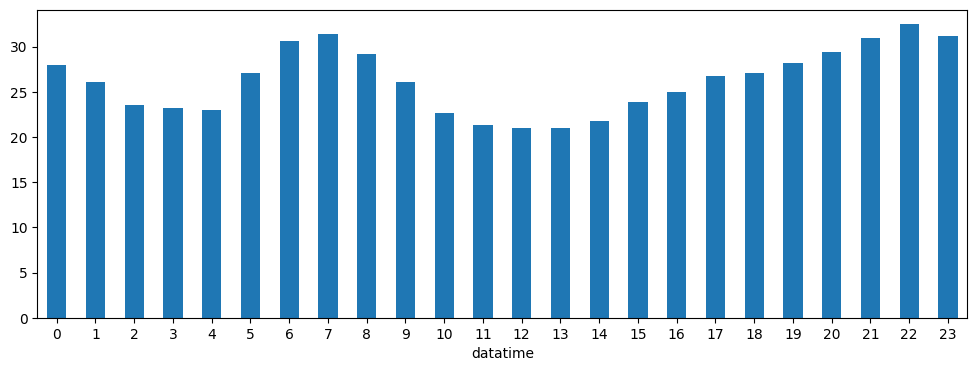

In [ ]:
fig, axs = plt.subplots(figsize=(12, 4))
air_quality.groupby(air_quality['datatime'].dt.hour)['value'].mean().plot(kind='bar', rot=0, ax=axs)

#Datetime as index

Create a plot of the
𝑁⁢𝑂2
 values in the different stations from May 20th till the end of May 21st.

In [ ]:
no2 = air_quality.pivot(index='datatime', columns='location', values='value').sort_index()

In [ ]:
no2.head()

location,BETR801,FR04014,London Westminster
datatime,,,
2019-05-07 01:00:00+00:00,50.5,25.0,23.0
2019-05-07 02:00:00+00:00,45.0,27.7,19.0
2019-05-07 03:00:00+00:00,NaN,50.4,19.0
2019-05-07 04:00:00+00:00,NaN,61.9,16.0
2019-05-07 05:00:00+00:00,NaN,72.4,NaN


<Axes: xlabel='datatime'>

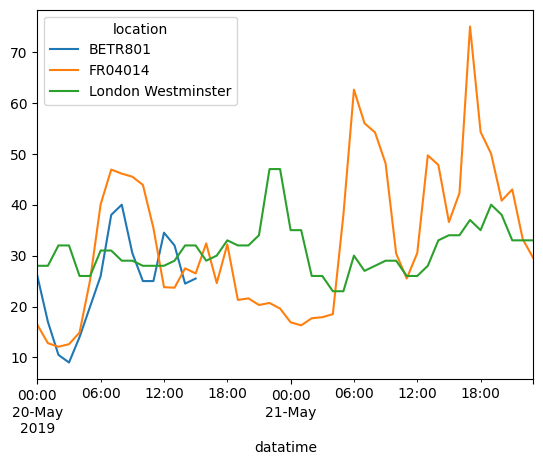

In [ ]:
no2['2019-05-20' : '2019-05-21'].plot()

#Resample a time series to another frequency

resample() groups time-series data into time intervals.

Aggregate the current hourly time series values to the monthly maximum value in each of the stations

In [ ]:
monthly_max = no2.resample('MS').max()

| Code   | Meaning     |
| ------ | ----------- |
| `"H"`  | Hourly      |
| `"D"`  | Daily       |
| `"W"`  | Weekly      |
| `"MS"` | Month start |
| `"ME"` | Month end   |
| `"YS"` | Year start  |


In [ ]:
monthly_max

location,BETR801,FR04014,London Westminster
datatime,,,
2019-05-01 00:00:00+00:00,74.5,97.0,97.0
2019-06-01 00:00:00+00:00,52.5,84.7,52.0


Make a plot of the daily mean
𝑁⁢𝑂2
 value in each of the stations.

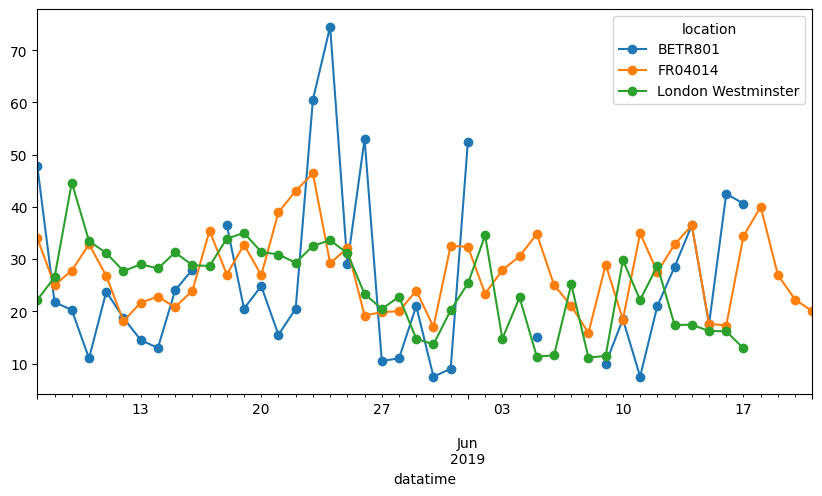

In [ ]:
no2.resample('D').mean().plot(style= '-o', figsize=(10,5));

| Symbol | Meaning                        |
| ------ | ------------------------------ |
| `-`    | draw connecting line           |
| `o`    | place circle markers on points |
